<a href="https://colab.research.google.com/github/hugo1911/ProyectoICOP2/blob/master/ICOP2_Deteccion_de_planta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Clasificacion de Enfermedades en Plantas con Deep Learning
### Proyecto segundo parcial — Deep Learning | CETYS Universidad
---

## 0. Instalacion y descarga del dataset

In [7]:
!pip install kagglehub -q

In [8]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_f02f85a2b7d40ec71deaf7bf6c3258c3"
#

import kagglehub
path = kagglehub.dataset_download("rashikrahmanpritom/plant-disease-recognition-dataset")
print("Dataset descargado en:", path)

Using Colab cache for faster access to the 'plant-disease-recognition-dataset' dataset.
Dataset descargado en: /kaggle/input/plant-disease-recognition-dataset


In [9]:

base = os.path.join(path, '1')

TRAIN_DIR = os.path.join(base, 'Train', 'Train')
VAL_DIR   = os.path.join(base, 'Validation', 'Validation')
TEST_DIR  = os.path.join(base, 'Test', 'Test')

for name, d in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    status = '✓' if os.path.exists(d) else '✗'
    print(f"{status} {name}: {d}")

✗ Train: /kaggle/input/plant-disease-recognition-dataset/1/Train/Train
✗ Val: /kaggle/input/plant-disease-recognition-dataset/1/Validation/Validation
✗ Test: /kaggle/input/plant-disease-recognition-dataset/1/Test/Test


---
## 1. EDA — Análisis Exploratorio de Datos

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

PyTorch version: 2.10.0+cpu
Dispositivo: cpu


In [11]:
import os


if os.path.exists('/kaggle/input'):

    base = '/kaggle/input/plant-disease-recognition-dataset'
else:

    base = os.path.join(path, '1')


def find_dir(base, names):
    for name in names:
        candidate = os.path.join(base, name, name)
        if os.path.exists(candidate):
            return candidate
        candidate = os.path.join(base, name)
        if os.path.exists(candidate):
            return candidate
    return None

TRAIN_DIR = find_dir(base, ['Train', 'train', 'training'])
VAL_DIR   = find_dir(base, ['Validation', 'validation', 'val'])
TEST_DIR  = find_dir(base, ['Test', 'test'])

for name, d in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    status = '✓' if d and os.path.exists(d) else '✗'
    print(f"{status} {name}: {d}")

✓ Train: /kaggle/input/plant-disease-recognition-dataset/Train/Train
✓ Val: /kaggle/input/plant-disease-recognition-dataset/Validation/Validation
✓ Test: /kaggle/input/plant-disease-recognition-dataset/Test/Test


In [12]:
# Clases disponibles
classes = sorted(os.listdir(TRAIN_DIR))
num_classes = len(classes)
print(f"Total de clases: {num_classes}")
for c in classes:
    print(" -", c)

Total de clases: 3
 - Healthy
 - Powdery
 - Rust


         Train  Validación  Test
Healthy    458          20    50
Powdery    430          20    50
Rust       434          20    50

Total — Train: 1322 | Val: 60 | Test: 150


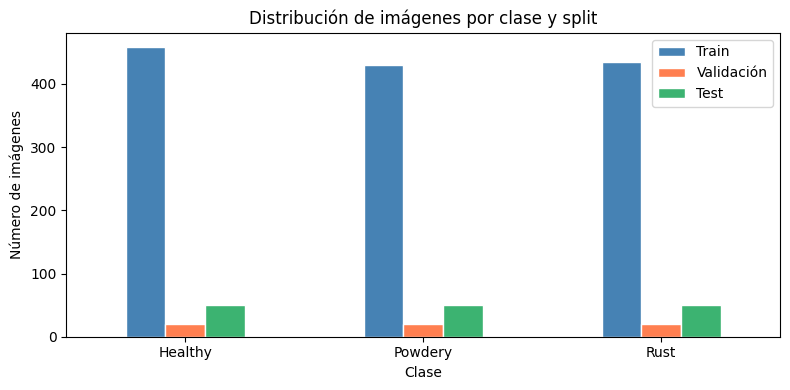

In [13]:
# Conteo de imagenes por clase en cada split
def count_images(base_dir):
    counts = {}
    for cls in sorted(os.listdir(base_dir)):
        cls_path = os.path.join(base_dir, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

df_counts = pd.DataFrame({'Train': train_counts, 'Validación': val_counts, 'Test': test_counts})
print(df_counts)
print(f"\nTotal — Train: {df_counts['Train'].sum()} | Val: {df_counts['Validación'].sum()} | Test: {df_counts['Test'].sum()}")

df_counts.plot(kind='bar', figsize=(8, 4), edgecolor='white', color=['steelblue','coral','mediumseagreen'])
plt.title('Distribución de imágenes por clase y split')
plt.ylabel('Número de imágenes')
plt.xlabel('Clase')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

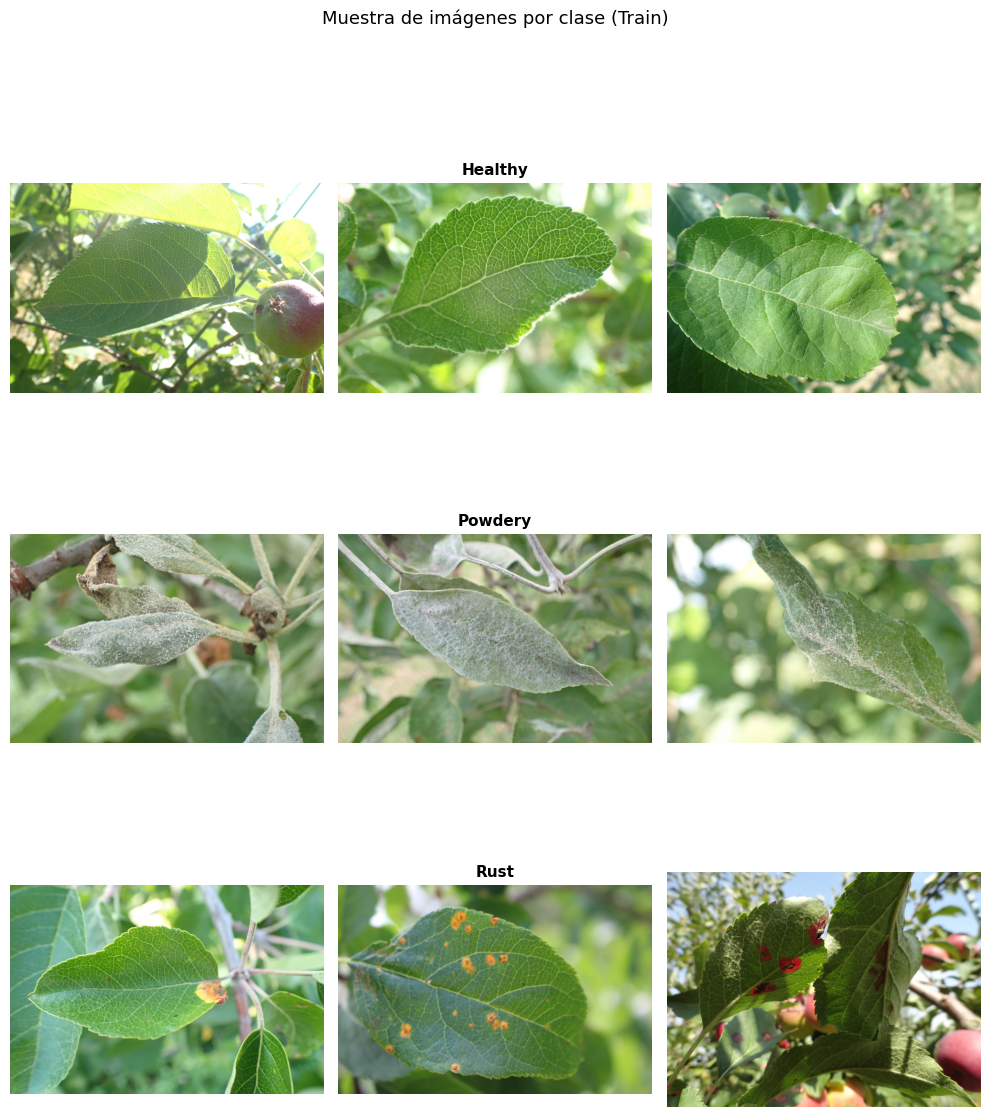

In [14]:
# Muestreo visual  3 imágenes por clase
fig, axes = plt.subplots(len(classes), 3, figsize=(10, 4 * len(classes)))
for row, cls in enumerate(classes):
    cls_path = os.path.join(TRAIN_DIR, cls)
    imgs_files = os.listdir(cls_path)[:3]
    for col, fname in enumerate(imgs_files):
        img = mpimg.imread(os.path.join(cls_path, fname))
        axes[row][col].imshow(img)
        axes[row][col].set_title(f"{cls}" if col == 1 else "", fontsize=11, fontweight='bold')
        axes[row][col].axis('off')
plt.suptitle('Muestra de imágenes por clase (Train)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Ancho  — min: 2592, max: 5184, promedio: 3986
Alto   — min: 1728, max: 3456, promedio: 2720


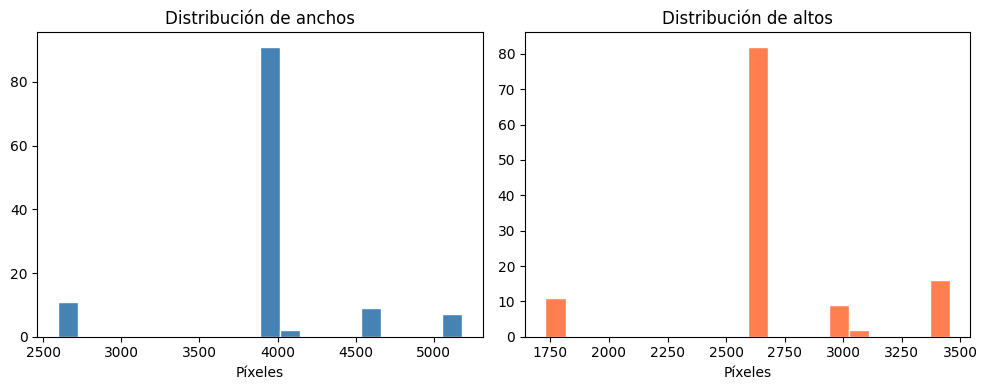

In [15]:

widths, heights = [], []
for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_path)[:40]:
        try:
            img = Image.open(os.path.join(cls_path, fname))
            widths.append(img.width)
            heights.append(img.height)
        except:
            pass

print(f"Ancho  — min: {min(widths)}, max: {max(widths)}, promedio: {np.mean(widths):.0f}")
print(f"Alto   — min: {min(heights)}, max: {max(heights)}, promedio: {np.mean(heights):.0f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.hist(widths,  bins=20, color='steelblue', edgecolor='white')
ax1.set_title('Distribución de anchos')
ax1.set_xlabel('Píxeles')
ax2.hist(heights, bins=20, color='coral', edgecolor='white')
ax2.set_title('Distribución de altos')
ax2.set_xlabel('Píxeles')
plt.tight_layout()
plt.show()

---
## 2. Preprocesamiento

Las transformaciones se definen como pipeline de torchvision y se aplican al cargar cada imagen. Las de entrenamiento incluyen data augmentation para mejorar la generalización del modelo.

In [16]:
IMG_SIZE   = 224
BATCH_SIZE = 32

# Transformaciones para entrenamiento con data augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),

    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Transformaciones para validacion  y test
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transformaciones definidas ✓")
print("\nTrain transforms:", train_transforms)
print("\nVal/Test transforms:", val_transforms)

Transformaciones definidas ✓

Train transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.2)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Val/Test transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [17]:
# Cargar los tres splits con ImageFolder
# El dataset ya viene dividido en Train / Validation / Test
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=VAL_DIR,   transform=val_transforms)
test_dataset  = datasets.ImageFolder(root=TEST_DIR,  transform=val_transforms)

class_names = train_dataset.classes
num_classes  = len(class_names)

print(f"Clases ({num_classes}): {class_names}")
print(f"Train:      {len(train_dataset)} imágenes")
print(f"Validación: {len(val_dataset)} imágenes")
print(f"Test:       {len(test_dataset)} imágenes")

Clases (3): ['Healthy', 'Powdery', 'Rust']
Train:      1322 imágenes
Validación: 60 imágenes
Test:       150 imágenes


In [18]:
# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


imgs, labels = next(iter(train_loader))
print(f"Shape de un batch: {imgs.shape}")
print(f"Rango de valores:  [{imgs.min():.2f}, {imgs.max():.2f}]")
print(f"Labels ejemplo:    {labels[:8].tolist()}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Shape de un batch: torch.Size([32, 3, 224, 224])
Rango de valores:  [-2.12, 2.64]
Labels ejemplo:    [0, 0, 1, 1, 0, 2, 0, 0]


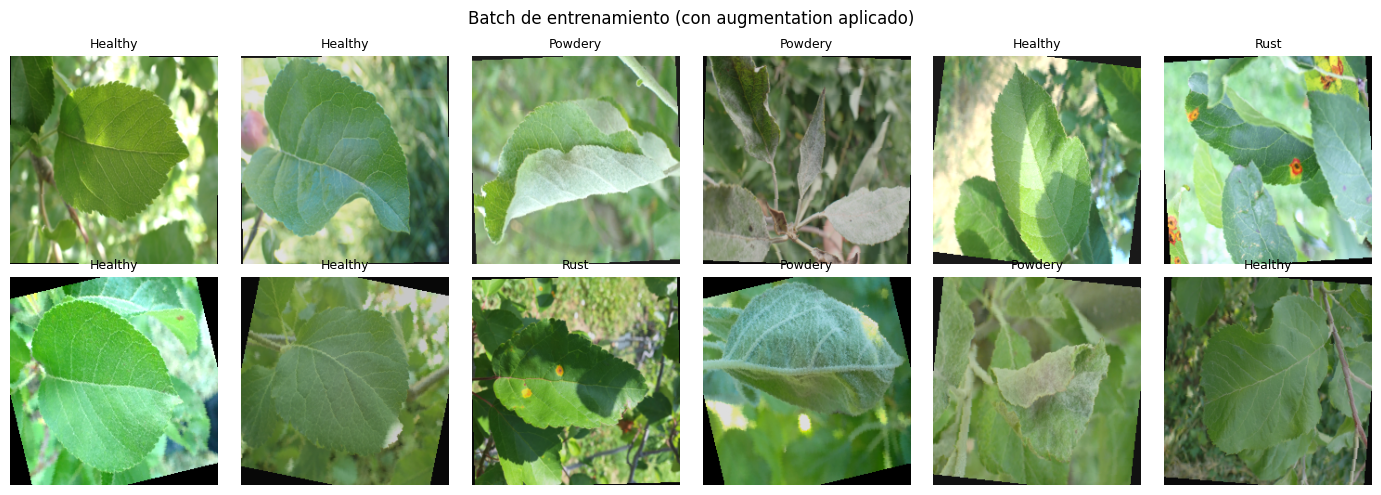

In [19]:
# Visualizar un batch con augmentation aplicado
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

n_show = min(12, len(imgs))
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i, ax in enumerate(axes.flatten()[:n_show]):
    img = denormalize(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(class_names[labels[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('Batch de entrenamiento (con augmentation aplicado)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 3. Entrenamiento del modelo

Se haran tres arquitecturas distintas:
- **Modelo 1**: CNN personalizada entrenada desde cero
- **Modelo 2**: ResNet-18 con transfer learning
- **Modelo 3**: EfficientNet-B0 con transfer learning

In [20]:
def train_model(model, train_loader, val_loader, num_epochs=20, lr=1e-3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        #  TRAIN
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total   += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total


        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * imgs.size(0)
                _, preds = outputs.max(1)
                correct += preds.eq(labels).sum().item()
                total   += labels.size(0)

        val_loss = running_loss / total
        val_acc  = correct / total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        scheduler.step()

        print(f"Epoch {epoch+1:02d}/{num_epochs} | "
              f"Train loss: {train_loss:.4f}  acc: {train_acc:.4f} | "
              f"Val loss: {val_loss:.4f}  acc: {val_acc:.4f}")

    return model, history


def plot_learning_curves(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history['train_loss'], label='Train',      color='steelblue')
    ax1.plot(epochs, history['val_loss'],   label='Validación', color='coral')
    ax1.set_title(f'{title} — Loss')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(epochs, history['train_acc'], label='Train',      color='steelblue')
    ax2.plot(epochs, history['val_acc'],   label='Validación', color='coral')
    ax2.set_title(f'{title} — Accuracy')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

print("Funciones de entrenamiento listas ")

Funciones de entrenamiento listas ✓


### Modelo 1 — CNN personalizada (desde cero)

In [21]:
class CustomCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # Bloque 1: 3 → 32 canales
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 2: 32 → 64 canales
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 3: 64 → 128 canales
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model1 = CustomCNN(num_classes)
total_params = sum(p.numel() for p in model1.parameters())
print(f"CustomCNN — parámetros totales: {total_params:,}")

CustomCNN — parámetros totales: 619,011


  ENTRENANDO: Modelo 1 — CustomCNN
Epoch 01/20 | Train loss: 0.7685  acc: 0.6762 | Val loss: 0.4968  acc: 0.7833
Epoch 02/20 | Train loss: 0.4224  acc: 0.8351 | Val loss: 0.3201  acc: 0.8667
Epoch 03/20 | Train loss: 0.3581  acc: 0.8797 | Val loss: 0.3892  acc: 0.8500
Epoch 04/20 | Train loss: 0.2975  acc: 0.8903 | Val loss: 0.2606  acc: 0.9000
Epoch 05/20 | Train loss: 0.2942  acc: 0.8949 | Val loss: 0.2479  acc: 0.9333
Epoch 06/20 | Train loss: 0.2213  acc: 0.9221 | Val loss: 0.2014  acc: 0.9167
Epoch 07/20 | Train loss: 0.2243  acc: 0.9259 | Val loss: 0.1345  acc: 0.9333
Epoch 08/20 | Train loss: 0.1691  acc: 0.9418 | Val loss: 0.1646  acc: 0.9500
Epoch 09/20 | Train loss: 0.1633  acc: 0.9387 | Val loss: 0.1205  acc: 0.9500
Epoch 10/20 | Train loss: 0.1394  acc: 0.9478 | Val loss: 0.1002  acc: 0.9667
Epoch 11/20 | Train loss: 0.1403  acc: 0.9523 | Val loss: 0.1039  acc: 0.9500
Epoch 12/20 | Train loss: 0.1664  acc: 0.9448 | Val loss: 0.1334  acc: 0.9667
Epoch 13/20 | Train loss: 0.1

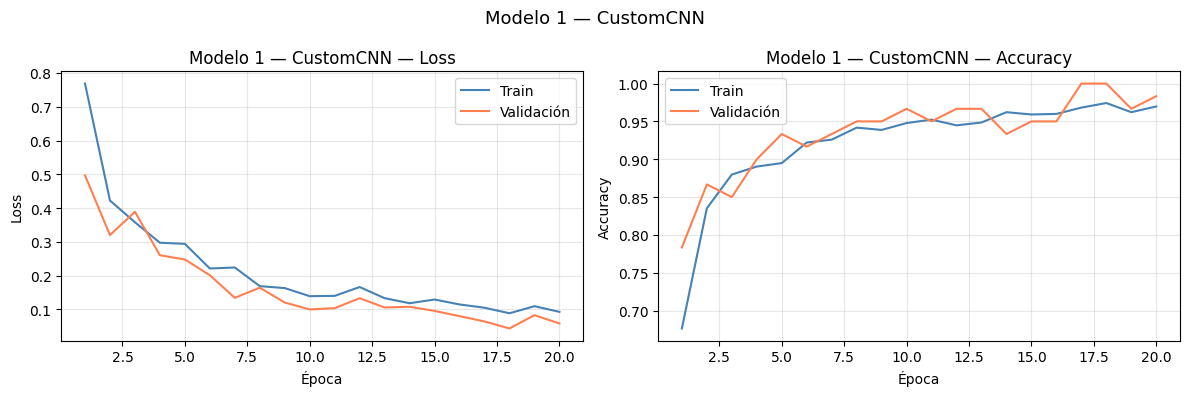

In [22]:
NUM_EPOCHS = 20

print("=" * 65)
print("  ENTRENANDO: Modelo 1 — CustomCNN")
print("=" * 65)
model1, history1 = train_model(model1, train_loader, val_loader,
                               num_epochs=NUM_EPOCHS, lr=1e-3)
plot_learning_curves(history1, 'Modelo 1 — CustomCNN')

### Modelo 2 — ResNet-18 (Transfer Learning)

In [23]:
# Cargar ResNet-18 preentrenado en ImageNet
model2 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)


for param in model2.parameters():
    param.requires_grad = False


in_features = model2.fc.in_features
model2.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)

trainable = sum(p.numel() for p in model2.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model2.parameters())
print(f"ResNet-18 — parámetros entrenables: {trainable:,} / {total:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 145MB/s]


ResNet-18 — parámetros entrenables: 132,099 / 11,308,611


  ENTRENANDO: Modelo 2 — ResNet-18
Epoch 01/20 | Train loss: 0.5850  acc: 0.7413 | Val loss: 0.1556  acc: 0.9667
Epoch 02/20 | Train loss: 0.2611  acc: 0.9145 | Val loss: 0.1526  acc: 0.9667
Epoch 03/20 | Train loss: 0.2265  acc: 0.9191 | Val loss: 0.1016  acc: 0.9333
Epoch 04/20 | Train loss: 0.1956  acc: 0.9357 | Val loss: 0.0897  acc: 0.9667
Epoch 05/20 | Train loss: 0.1737  acc: 0.9440 | Val loss: 0.1243  acc: 0.9667
Epoch 06/20 | Train loss: 0.1833  acc: 0.9425 | Val loss: 0.0986  acc: 0.9667
Epoch 07/20 | Train loss: 0.2184  acc: 0.9213 | Val loss: 0.0987  acc: 0.9667
Epoch 08/20 | Train loss: 0.1428  acc: 0.9546 | Val loss: 0.0690  acc: 0.9667
Epoch 09/20 | Train loss: 0.1252  acc: 0.9554 | Val loss: 0.0766  acc: 0.9667
Epoch 10/20 | Train loss: 0.1251  acc: 0.9637 | Val loss: 0.0635  acc: 0.9667
Epoch 11/20 | Train loss: 0.1326  acc: 0.9470 | Val loss: 0.0656  acc: 0.9667
Epoch 12/20 | Train loss: 0.1361  acc: 0.9486 | Val loss: 0.0925  acc: 0.9667
Epoch 13/20 | Train loss: 0.1

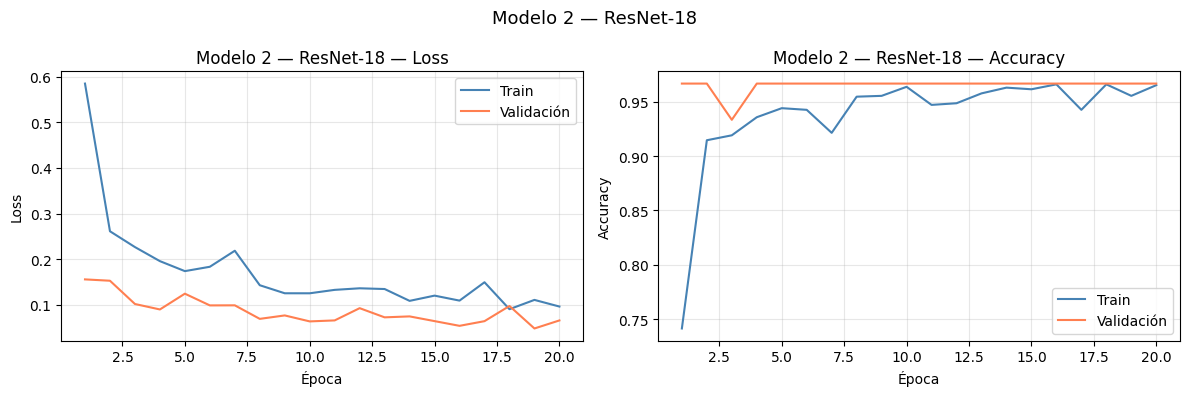

In [24]:
print("  ENTRENANDO: Modelo 2 — ResNet-18")

model2, history2 = train_model(model2, train_loader, val_loader,
                               num_epochs=NUM_EPOCHS, lr=1e-3)
plot_learning_curves(history2, 'Modelo 2 — ResNet-18')

### Modelo 3 — EfficientNet-B0 (Transfer Learning)

In [25]:
# Cargar EfficientNet-B0 preentrenado en ImageNet
model3 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)


for param in model3.features.parameters():
    param.requires_grad = False


in_features = model3.classifier[1].in_features
model3.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, num_classes)
)

trainable = sum(p.numel() for p in model3.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model3.parameters())
print(f"EfficientNet-B0 — parámetros entrenables: {trainable:,} / {total:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 62.6MB/s]

EfficientNet-B0 — parámetros entrenables: 3,843 / 4,011,391


  ENTRENANDO: Modelo 3 — EfficientNet-B0
Epoch 01/20 | Train loss: 0.8266  acc: 0.7383 | Val loss: 0.6175  acc: 0.9000
Epoch 02/20 | Train loss: 0.5272  acc: 0.8888 | Val loss: 0.4471  acc: 0.9167
Epoch 03/20 | Train loss: 0.4108  acc: 0.9100 | Val loss: 0.3756  acc: 0.9500
Epoch 04/20 | Train loss: 0.3372  acc: 0.9244 | Val loss: 0.3283  acc: 0.9667
Epoch 05/20 | Train loss: 0.2959  acc: 0.9342 | Val loss: 0.2877  acc: 0.9667
Epoch 06/20 | Train loss: 0.2871  acc: 0.9236 | Val loss: 0.2646  acc: 0.9833
Epoch 07/20 | Train loss: 0.2657  acc: 0.9319 | Val loss: 0.2598  acc: 0.9667
Epoch 08/20 | Train loss: 0.2391  acc: 0.9418 | Val loss: 0.2449  acc: 0.9833
Epoch 09/20 | Train loss: 0.2327  acc: 0.9440 | Val loss: 0.2370  acc: 0.9667
Epoch 10/20 | Train loss: 0.2355  acc: 0.9402 | Val loss: 0.2242  acc: 0.9667
Epoch 11/20 | Train loss: 0.2265  acc: 0.9455 | Val loss: 0.2124  acc: 0.9667
Epoch 12/20 | Train loss: 0.2120  acc: 0.9440 | Val loss: 0.2143  acc: 0.9667
Epoch 13/20 | Train los

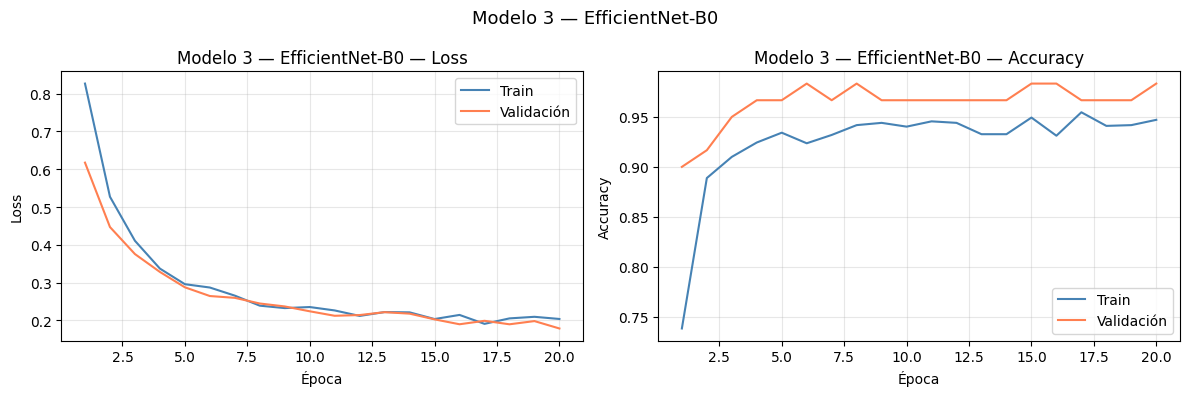

In [26]:
print("=" * 65)
print("  ENTRENANDO: Modelo 3 — EfficientNet-B0")
print("=" * 65)
model3, history3 = train_model(model3, train_loader, val_loader,
                               num_epochs=NUM_EPOCHS, lr=5e-4)
plot_learning_curves(history3, 'Modelo 3 — EfficientNet-B0')

---
## 4. Comparación y selección del mejor modelo

                 Val Accuracy  Val Loss  Overfitting (train-val acc)
CustomCNN              1.0000    0.0438                      -0.0257
ResNet-18              0.9667    0.0479                      -0.0007
EfficientNet-B0        0.9833    0.1788                      -0.0287


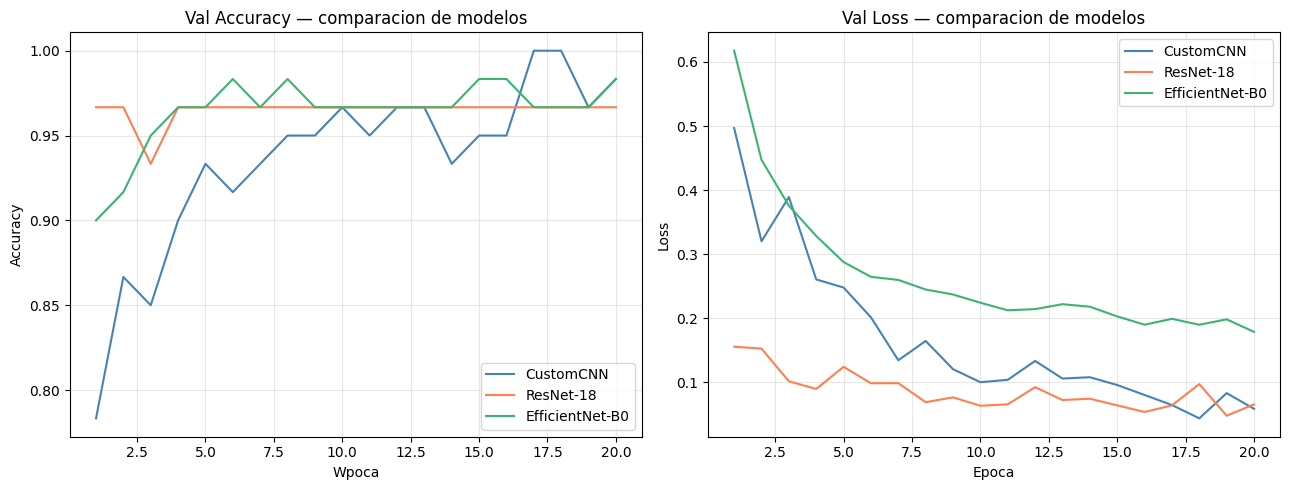


 Mejor modelo: CustomCNN
   Val Accuracy : 1.0000
   Overfitting  : -0.0257


In [27]:
# Resumen de metricas
summary = {
    'CustomCNN': {
        'Val Accuracy':               max(history1['val_acc']),
        'Val Loss':                   min(history1['val_loss']),
        'Overfitting (train-val acc)': max(history1['train_acc']) - max(history1['val_acc'])
    },
    'ResNet-18': {
        'Val Accuracy':               max(history2['val_acc']),
        'Val Loss':                   min(history2['val_loss']),
        'Overfitting (train-val acc)': max(history2['train_acc']) - max(history2['val_acc'])
    },
    'EfficientNet-B0': {
        'Val Accuracy':               max(history3['val_acc']),
        'Val Loss':                   min(history3['val_loss']),
        'Overfitting (train-val acc)': max(history3['train_acc']) - max(history3['val_acc'])
    },
}

df_summary = pd.DataFrame(summary).T.round(4)
print(df_summary)

# Curvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for hist, name, color in [
    (history1, 'CustomCNN',       'steelblue'),
    (history2, 'ResNet-18',       'coral'),
    (history3, 'EfficientNet-B0', 'mediumseagreen')
]:
    ep = range(1, len(hist['val_acc']) + 1)
    ax1.plot(ep, hist['val_acc'],  label=name, color=color)
    ax2.plot(ep, hist['val_loss'], label=name, color=color)

ax1.set_title('Val Accuracy — comparacion de modelos')
ax1.set_xlabel('Wpoca')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.set_title('Val Loss — comparacion de modelos')
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Seleccion automatica del mejor modelo
best_name  = df_summary['Val Accuracy'].idxmax()
best_model = {'CustomCNN': model1, 'ResNet-18': model2, 'EfficientNet-B0': model3}[best_name]
print(f"\n Mejor modelo: {best_name}")
print(f"   Val Accuracy : {df_summary.loc[best_name, 'Val Accuracy']:.4f}")
print(f"   Overfitting  : {df_summary.loc[best_name, 'Overfitting (train-val acc)']:.4f}")

---
## 5. Serialización del mejor modelo

Se guarda el modelo en formato `.pth` usando `state_dict` de PyTorch. Se incluyen también los metadatos necesarios para deserializarlo correctamente en la aplicación.

In [28]:
save_path = f"best_model_{best_name.replace('-','_').replace(' ','_').lower()}.pth"

torch.save({
    'model_name':  best_name,
    'num_classes': num_classes,
    'class_names': class_names,
    'img_size':    IMG_SIZE,
    'state_dict':  best_model.state_dict(),
}, save_path)

print(f"Modelo guardado: {save_path}")
print(f"Formato        : PyTorch state_dict (.pth)")
print(f"Clases guardadas: {class_names}")
print()
print("  checkpoint = torch.load('archivo.pth', map_location=device)")
print("  model.load_state_dict(checkpoint['state_dict'])")

# Descargar a la computadora solo funciona en Colab
from google.colab import files
files.download(save_path)

Modelo guardado: best_model_customcnn.pth
Formato        : PyTorch state_dict (.pth)
Clases guardadas: ['Healthy', 'Powdery', 'Rust']

  checkpoint = torch.load('archivo.pth', map_location=device)
  model.load_state_dict(checkpoint['state_dict'])


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Guardado para onnx**

In [30]:
!pip install onnxscript onnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 10.3 MB/s eta 0:00:00


In [45]:
#Exportar modelo a ONNX
import torch

onnx_path = f"best_model_{best_name.replace('-','_').replace(' ','_').lower()}.onnx"

best_model.eval()
best_model.to("cpu")


dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

torch.onnx.export(
    best_model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input":  {0: "batch_size"},
        "output": {0: "batch_size"},
    },
)

print(f" Modelo ONNX exportado: {onnx_path}")


try:
    import onnx
    model_onnx = onnx.load(onnx_path)
    onnx.checker.check_model(model_onnx)

except ImportError:
    print("   (instala onnx con: pip install onnx -q para verificar)")

# Descargar en Colab
try:
    from google.colab import files
    files.download(onnx_path)
except:
    print("   (descarga manual si no estas en Colab)")

/tmp/ipykernel_6199/4134804968.py:12: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0422 22:01:15.867000 6199 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0422 22:01:16.559000 6199 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' =

[torch.onnx] Obtain model graph for `CustomCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CustomCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
 Modelo ONNX exportado: best_model_customcnn.onnx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
##  Siguiente: Parte 2

La **Parte 2** del notebook tendra:
- Evaluacion del mejor modelo en el conjunto de **test**
- Reporte de clasificacion (precision, recall, F1-score por clase)
- Matriz de confusion
- Comparacion train vs test para descartar overfitting
- Visualizacion de predicciones correctas e incorrectas

#  Clasificación de Plantas — Parte 2
### Evaluacin del modelo en conjunto de prueba
---

Esta segunda parte  la **Parte 1** ya fue ejecutada en la misma sesion,
por lo que las variables `best_model`, `best_name`, `class_names`, `test_loader`,
`train_loader`, `history1/2/3` y `device` ya estan en memoria.



---
## 6. Evaluacion del mejor modelo en el conjunto de prueba

Se evalua **CustomCNN** (mejor modelo por Val Accuracy) sobre el conjunto de test,
que el modelo nunca vio durante el entrenamiento ni la seleccion de hiperparametros.

In [46]:
#checar rutas
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

# Rutas directas
TRAIN_DIR = '/kaggle/input/plant-disease-recognition-dataset/Train/Train'
VAL_DIR   = '/kaggle/input/plant-disease-recognition-dataset/Validation/Validation'
TEST_DIR  = '/kaggle/input/plant-disease-recognition-dataset/Test/Test'

for name, d in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    print(f"{'✓' if os.path.exists(d) else '✗'} {name}: {d}")

Dispositivo: cpu
✓ Train: /kaggle/input/plant-disease-recognition-dataset/Train/Train
✓ Val: /kaggle/input/plant-disease-recognition-dataset/Validation/Validation
✓ Test: /kaggle/input/plant-disease-recognition-dataset/Test/Test


In [47]:
import os

base = '/kaggle/input/plant-disease-recognition-dataset'
print("Existe", os.path.exists(base))
print()
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level > 3:
        break

Existe True

plant-disease-recognition-dataset/
  Validation/
    Validation/
      Healthy/
      Rust/
      Powdery/
  Test/
    Test/
      Healthy/
      Rust/
      Powdery/
  Train/
    Train/
      Healthy/
      Rust/
      Powdery/


In [48]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)


best_model.eval()
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for batch_imgs, batch_labels in test_loader:
        batch_imgs = batch_imgs.to(device)
        outputs    = best_model(batch_imgs)
        probs      = torch.softmax(outputs, dim=1)
        _, preds   = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

test_accuracy = accuracy_score(all_labels, all_preds)
test_f1       = f1_score(all_labels, all_preds, average='weighted')

print(f"Modelo evaluado : {best_name}")
print(f"Test Accuracy   : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print(f"Test F1-score   : {test_f1:.4f}  (weighted)")
print(f"Total imagenes  : {len(all_labels)}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Modelo evaluado : CustomCNN
Test Accuracy   : 0.9600  (96.00%)
Test F1-score   : 0.9604  (weighted)
Total imagenes  : 150


---
## 7. Reporte de clasificacion por clase

              precision    recall  f1-score   support

     Healthy       0.89      1.00      0.94        50
     Powdery       1.00      0.92      0.96        50
        Rust       1.00      0.96      0.98        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



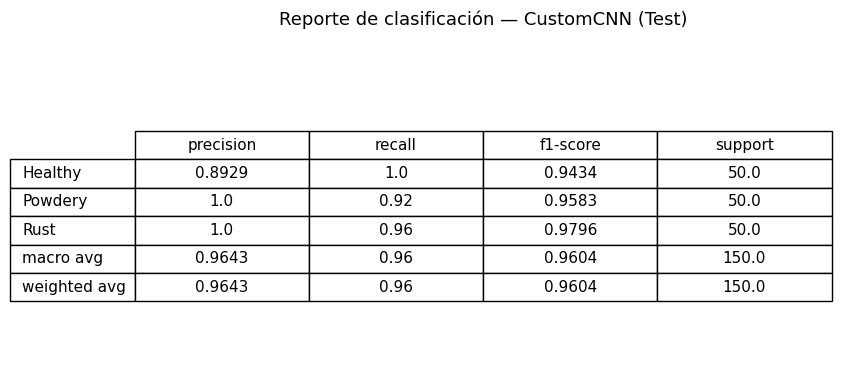

In [49]:
 #precision, recall, F1 por clase
report = classification_report(
    all_labels, all_preds,
    target_names=class_names,
    output_dict=True
)

print(classification_report(all_labels, all_preds, target_names=class_names))

# Tabla visual
df_report = pd.DataFrame(report).T.drop(['accuracy'], errors='ignore')
df_report = df_report[['precision', 'recall', 'f1-score', 'support']].round(4)

fig, ax = plt.subplots(figsize=(9, len(df_report) * 0.6 + 1))
ax.axis('off')
table = ax.table(
    cellText=df_report.values,
    colLabels=df_report.columns,
    rowLabels=df_report.index,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 1.6)
plt.title(f'Reporte de clasificación — {best_name} (Test)', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

---
## 8. Matriz de confusion

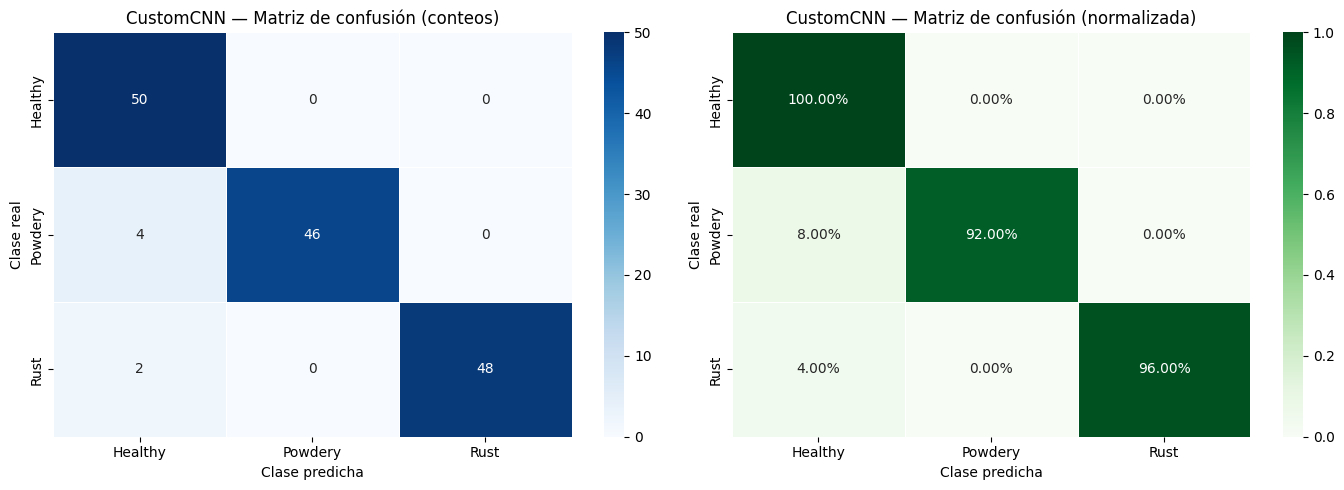


Errores por clase:
  Healthy      — correctas: 50/50  errores: 0
  Powdery      — correctas: 46/50  errores: 4
  Rust         — correctas: 48/50  errores: 2


In [50]:
cm = confusion_matrix(all_labels, all_preds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de conteos absolutos
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    ax=ax1, linewidths=0.5
)
ax1.set_title(f'{best_name} — Matriz de confusión (conteos)', fontsize=12)
ax1.set_ylabel('Clase real')
ax1.set_xlabel('Clase predicha')

# Matriz normalizada
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Greens',
    xticklabels=class_names, yticklabels=class_names,
    ax=ax2, linewidths=0.5, vmin=0, vmax=1
)
ax2.set_title(f'{best_name} — Matriz de confusión (normalizada)', fontsize=12)
ax2.set_ylabel('Clase real')
ax2.set_xlabel('Clase predicha')

plt.tight_layout()
plt.show()

# Errores por clase
print("\nErrores por clase:")
for i, cls in enumerate(class_names):
    total   = cm[i].sum()
    correct = cm[i][i]
    errors  = total - correct
    print(f"  {cls:12s} — correctas: {correct}/{total}  errores: {errors}")

---
## 9. Comparacion Train vs Test — deteccion de overfitting

                 Conjunto  Accuracy     Loss
     Train (último epoch)  0.969743 0.093021
Validación (último epoch)  0.983333 0.058719
                     Test  0.960000      NaN

Gap Train-Test (overfitting): +0.0097
No se detecta overfitting significativo (gap < 5%)


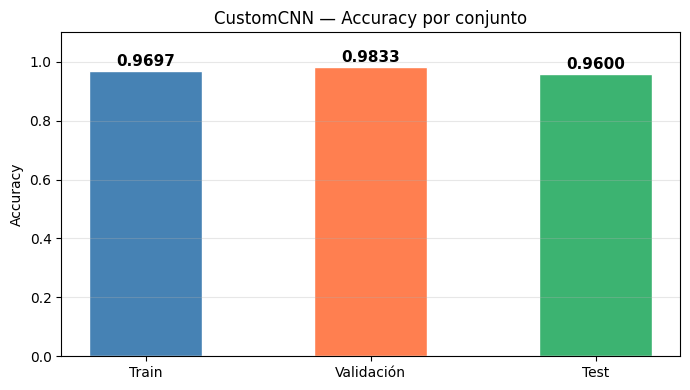

In [51]:
# Accuracy del modelo en train
# Usamos history del mejor modelo (CustomCNN = history1)
history_best = {'CustomCNN': history1, 'ResNet-18': history2, 'EfficientNet-B0': history3}[best_name]

final_train_acc = history_best['train_acc'][-1]
final_val_acc   = history_best['val_acc'][-1]
final_train_loss = history_best['train_loss'][-1]
final_val_loss   = history_best['val_loss'][-1]

overfitting_gap = final_train_acc - test_accuracy

df_ov = pd.DataFrame({
    'Conjunto':  ['Train (último epoch)', 'Validación (último epoch)', 'Test'],
    'Accuracy':  [final_train_acc, final_val_acc, test_accuracy],
    'Loss':      [final_train_loss, final_val_loss, None]
})
print(df_ov.to_string(index=False))
print(f"\nGap Train-Test (overfitting): {overfitting_gap:+.4f}")

if abs(overfitting_gap) < 0.05:
    print("No se detecta overfitting significativo (gap < 5%)")
elif overfitting_gap > 0.05:
    print("  Posible overfitting detectado — el modelo rinde mejor en train que en test")
else:
    print("ℹ El modelo rinde mejor en test que en train (poco común, revisar datos)")

# Grafica comparativa
fig, ax = plt.subplots(figsize=(7, 4))
conjuntos = ['Train', 'Validación', 'Test']
accs      = [final_train_acc, final_val_acc, test_accuracy]
colors    = ['steelblue', 'coral', 'mediumseagreen']
bars = ax.bar(conjuntos, accs, color=colors, edgecolor='white', width=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title(f'{best_name} — Accuracy por conjunto')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()